# Czech UGS Storage Obligations — Monthly Regulatory Requirements

**Question this notebook answers**
What volume of working gas must be held in Czech UGS at the **start of each
heating-season month** (Oct–Mar) so that a 30-day peak-demand stress event
(as defined in EU Regulation 2017/1938 Art. 6) can be survived, at each
import-risk scenario (S1–S5)?

**Regulatory framing**
Article 6 of the Gas Security of Supply Regulation requires that protected
customers be supplied during:
- A **7-day extreme cold spell** at the 1-in-20 daily peak demand (`R.max.den`).
- A broader **30-day period** whose total consumption is given by `r_30dnu`.

The Czech implementation pins this 30-day stress period to calendar months.
The two-tier demand profile: 7 days at `R.max.den` followed by 23 days at
the residual average implied by `r_30dnu`.

**Key design choices**
- Monthly obligations are **independent stress tests** — no carry-forward between months.
- Compliance checked at **month-start checkpoints** only (Oct 1, Nov 1, …, Mar 1).
- Withdrawal-rate constraint applied at each simulation step as fill depletes.
- **End-of-season reserve:** ~0.5 TWh at Mar 31 recommended as a separate instrument.

*All analytical logic lives in `bsd`; this notebook calls the library and renders results.*

---
## 0. Setup

In [1]:
%cd ..
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import bsd
import bsd.jvs as jvs

jvs.apply_style(theme="light", context="notebook")
%matplotlib inline

SCENARIOS = bsd.DEFAULT_SCENARIOS_DICT

# ── Withdrawal curve (Branch 1: 50/50 blend, 10% haircut) ──
WC_ASSUMPTION       = "blend"
WC_BLEND_WEIGHT_ENG = 0.50   # Branch 1 default — see docs/wc_blend_decision.md
IMPORT_ASSUMPTION   = "p99_cold"   # controls which ceiling is shown in supplementary table

wc_curves = bsd.fit_withdrawal_curves()
wc_func = wc_curves.blend(eng_weight=WC_BLEND_WEIGHT_ENG)

print(f"WC assumption: {WC_ASSUMPTION}  (eng_weight={WC_BLEND_WEIGHT_ENG:.0%})")
print(f"WC at 20%: {wc_func(20):.1f}  40%: {wc_func(40):.1f}  60%: {wc_func(60):.1f}  80%: {wc_func(80):.1f}  GWh/d")

/Users/martinsik/Coding/bsd_revamp


WC assumption: blend  (eng_weight=50%)
WC at 20%: 244.6  40%: 445.5  60%: 496.5  80%: 499.5  GWh/d


---
## 1. Two-tier demand profile

In [2]:
prof = bsd.load_demand_profile()
peak_demand     = prof.peak
residual_demand = prof.residual

bsd.demand_profile_table(prof)

,Peak 7d (GWh/d),Residual 23d (GWh/d),Total 30d (GWh)
month_num,,,
Oct,163.2,118.7,3873.0
Nov,244.4,177.7,5798.0
Dec,325.4,236.6,7720.0
Jan,367.8,267.3,8723.0
Feb,326.7,237.5,7750.0
Mar,244.6,177.9,5805.0


---
## 2. Monthly import percentiles per scenario

In [3]:
monthly_imports = bsd.compute_monthly_imports(SCENARIOS)
p99_cold, p99_uncond = bsd.compute_import_benchmarks()

IMPORT_CEILING = {"p99_cold": p99_cold,
                  "p99_unconditional": p99_uncond}[IMPORT_ASSUMPTION]

imp_df = bsd.import_table(monthly_imports, p99_cold, p99_uncond)
print(f"Active ceiling assumption: {IMPORT_ASSUMPTION}")
imp_df

Active ceiling assumption: p99_cold


,S1,S2,S3,S4,S5,P99 unconditional,P99 cold days
Oct,183.3,212.5,237.0,299.2,356.9,589.6,360.9
Nov,147.8,159.8,230.6,284.4,342.0,635.1,351.6
Dec,137.1,141.6,150.0,259.7,340.9,390.8,387.5
Jan,113.0,135.0,164.2,213.8,272.0,365.6,217.3
Feb,120.2,148.9,185.4,215.0,243.9,313.5,258.3
Mar,153.9,195.8,215.5,253.6,350.4,820.2,742.7


---
## 3. Withdrawal-curve reference

Curves fitted by `bsd.fit_withdrawal_curves()` — see `bsd/withdrawal.py` for the
isotonic regression and engineering-curve logic.

In [4]:
print(f"WC_CURRENT: {wc_curves.wc_current:.1f} GWh/d")
print(f"Blend {WC_BLEND_WEIGHT_ENG:.0%}/{1-WC_BLEND_WEIGHT_ENG:.0%} eng/emp at key fill levels:")
for fp in [20, 40, 60, 80]:
    print(f"  {fp}%: {wc_func(fp):.1f} GWh/d  "
          f"(empirical: {wc_curves.empirical(fp):.1f},  "
          f"engineering: {wc_curves.engineering(fp):.1f})")

WC_CURRENT: 732.1 GWh/d
Blend 50%/50% eng/emp at key fill levels:
  20%: 244.6 GWh/d  (empirical: 126.7,  engineering: 362.5)
  40%: 445.5 GWh/d  (empirical: 340.4,  engineering: 550.7)
  60%: 496.5 GWh/d  (empirical: 346.4,  engineering: 646.7)
  80%: 499.5 GWh/d  (empirical: 346.4,  engineering: 652.6)


---
## 4. Main results — minimum starting fill per month per scenario

`bsd.run_all_months` loops over all scenarios and months, calling
`bsd.min_start_fill_month` (bisection) and `bsd.simulate_month` for each.

In [5]:
results = bsd.run_all_months(
    monthly_imports, wc_func, peak_demand, residual_demand, SCENARIOS,
)

oblig_twh = bsd.obligations_table(results, SCENARIOS)
print("Minimum required starting fill (TWh) per month per scenario")
oblig_twh

Minimum required starting fill (TWh) per month per scenario


,S1 — High stress,S2 — Stressed,S3 — Base stressed,S4 — Median,S5 — Favourable
Oct,0.00,0.00,0.00,0.00,0.00
Nov,1.36,1.01,0.10,0.00,0.00
Dec,4.50,4.12,3.41,0.46,0.00
Jan,10.56,8.54,5.85,2.31,0.67
Feb,6.12,3.62,2.19,1.30,0.58
Mar,1.19,0.34,0.21,0.00,0.00


In [6]:
# Fill-% version
oblig_pct = pd.DataFrame(
    {key: {bsd.MONTH_NAMES[m]: (
        None if results[key][m]["start_fill_pct"] is None
        else round(results[key][m]["start_fill_pct"], 1)
    ) for m in bsd.MONTH_ORDER}
     for key in SCENARIOS}
)
oblig_pct.columns = [SCENARIOS[k].label for k in SCENARIOS]
print("Minimum required starting fill (% of capacity) per month per scenario")
oblig_pct

Minimum required starting fill (% of capacity) per month per scenario


,S1 — High stress,S2 — Stressed,S3 — Base stressed,S4 — Median,S5 — Favourable
Oct,0.0,0.0,0.0,0.0,0.0
Nov,3.3,2.5,0.2,0.0,0.0
Dec,11.0,10.1,8.4,1.1,0.0
Jan,25.9,20.9,14.3,5.7,1.6
Feb,15.0,8.9,5.4,3.2,1.4
Mar,2.9,0.8,0.5,0.0,0.0


In [7]:
# Binding constraint table
binding_table = pd.DataFrame(
    {key: {bsd.MONTH_NAMES[m]: results[key][m]["binding"] for m in bsd.MONTH_ORDER}
     for key in SCENARIOS}
)
binding_table.columns = [SCENARIOS[k].label for k in SCENARIOS]
print("Binding constraint per month per scenario")
binding_table

Binding constraint per month per scenario


,S1 — High stress,S2 — Stressed,S3 — Base stressed,S4 — Median,S5 — Favourable
Oct,volume,volume,volume,volume,volume
Nov,volume,volume,volume,volume,volume
Dec,withdrawal rate,withdrawal rate,withdrawal rate,volume,volume
Jan,withdrawal rate,withdrawal rate,withdrawal rate,volume,volume
Feb,withdrawal rate,withdrawal rate,volume,volume,volume
Mar,volume,volume,volume,volume,volume


---
## 5. Charts

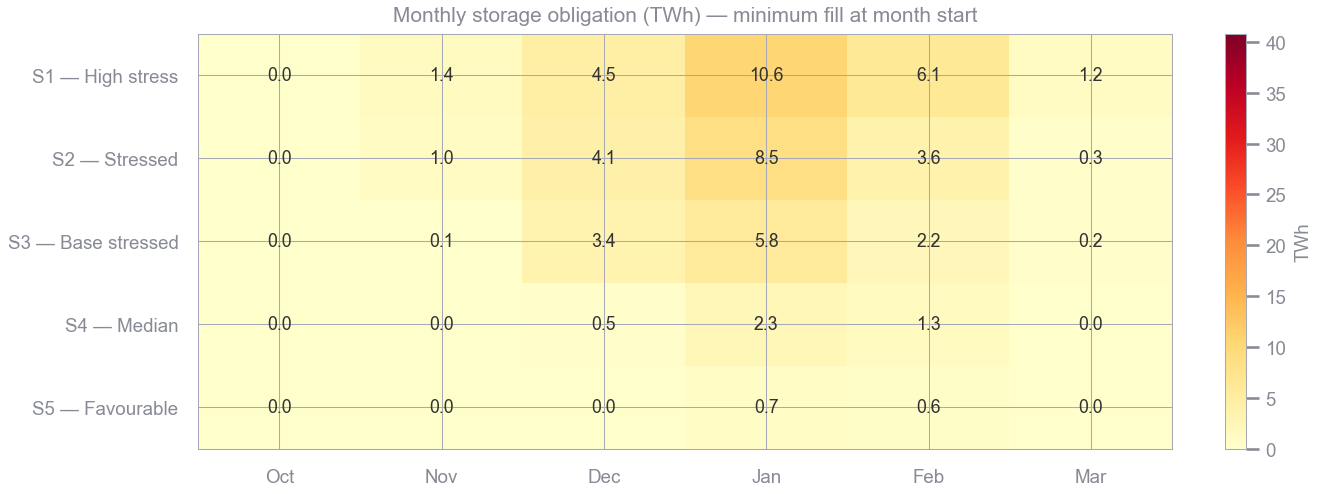

In [8]:
# Heatmap: obligation (TWh) by month × scenario
fig, ax = plt.subplots(figsize=(9, 3.5))
data_arr = oblig_twh.values.astype(float)
im = ax.imshow(data_arr.T, aspect="auto", cmap="YlOrRd", vmin=0, vmax=bsd.CAPACITY_TWH)
ax.set_xticks(range(len(bsd.MONTH_ORDER)))
ax.set_xticklabels([bsd.MONTH_NAMES[m] for m in bsd.MONTH_ORDER])
ax.set_yticks(range(len(SCENARIOS)))
ax.set_yticklabels([SCENARIOS[k].label for k in SCENARIOS])
for i, m in enumerate(bsd.MONTH_ORDER):
    for j, key in enumerate(SCENARIOS):
        v = results[key][m]["start_fill_TWh"]
        txt = f"{v:.1f}" if v is not None else "\u2014"
        ax.text(i, j, txt, ha="center", va="center", fontsize=8.5,
                color="white" if (v or 0) > bsd.CAPACITY_TWH * 0.55 else "#333333")
plt.colorbar(im, ax=ax, label="TWh", fraction=0.03)
ax.set_title("Monthly storage obligation (TWh) — minimum fill at month start")
fig.tight_layout()
fig.savefig("figs/storage_obligations_heatmap.png", bbox_inches="tight")
fig;

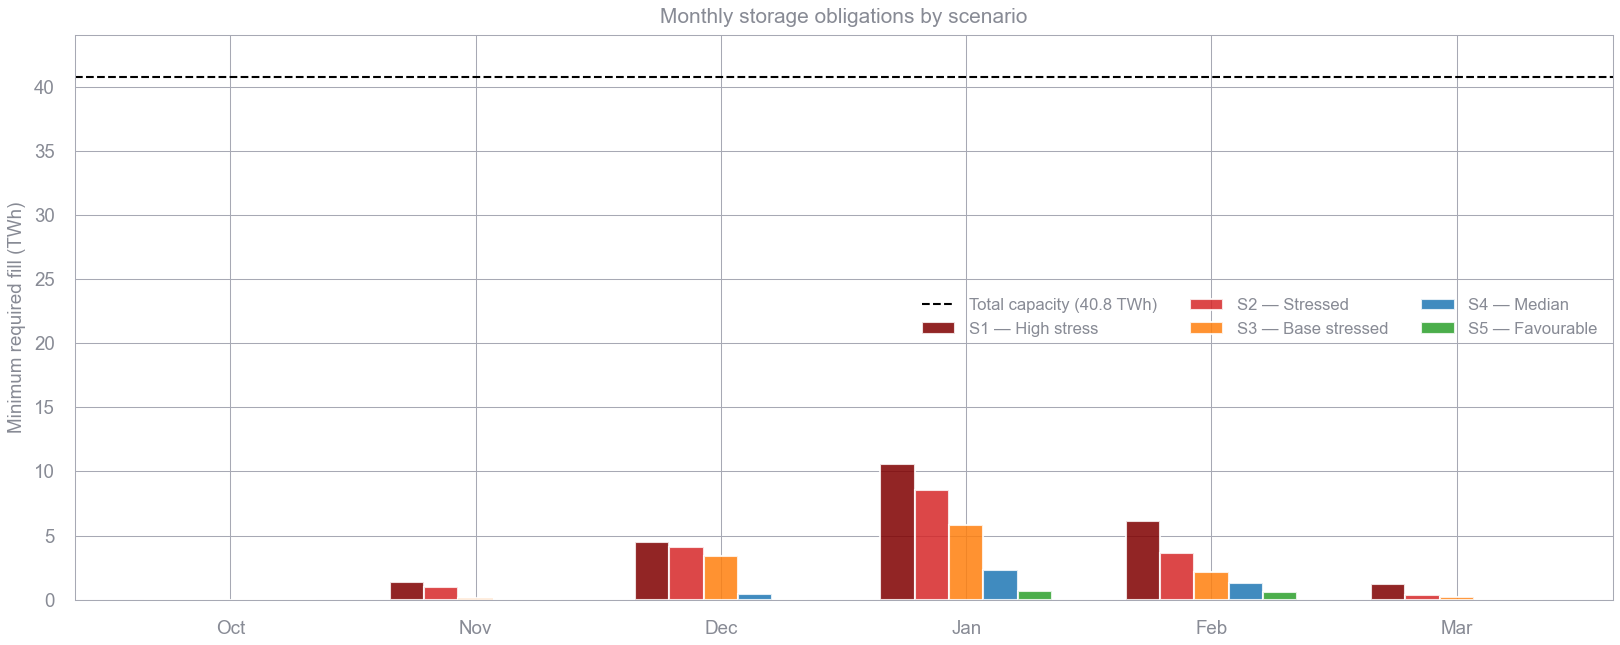

In [9]:
# Grouped bar: all months × scenarios
fig, ax = plt.subplots(figsize=(11, 4.5))
n_months, n_scen, width = len(bsd.MONTH_ORDER), len(SCENARIOS), 0.14
xs = np.arange(n_months)

for j, (key, sc) in enumerate(SCENARIOS.items()):
    vals = [results[key][m]["start_fill_TWh"] or 0.0 for m in bsd.MONTH_ORDER]
    offset = (j - n_scen / 2 + 0.5) * width
    ax.bar(xs + offset, vals, width=width, color=sc.color, alpha=0.85, label=sc.label)

ax.axhline(bsd.CAPACITY_TWH, color="black", lw=1.0, ls="--",
           label=f"Total capacity ({bsd.CAPACITY_TWH:.1f} TWh)")
ax.set_xticks(xs)
ax.set_xticklabels([bsd.MONTH_NAMES[m] for m in bsd.MONTH_ORDER])
ax.set_ylabel("Minimum required fill (TWh)")
ax.set_title("Monthly storage obligations by scenario")
ax.legend(fontsize=8, ncol=3)
ax.set_ylim(0, bsd.CAPACITY_TWH * 1.08)
jvs.grid(ax=ax)
fig.tight_layout()
fig.savefig("figs/storage_obligations_bar.png", bbox_inches="tight")
fig;

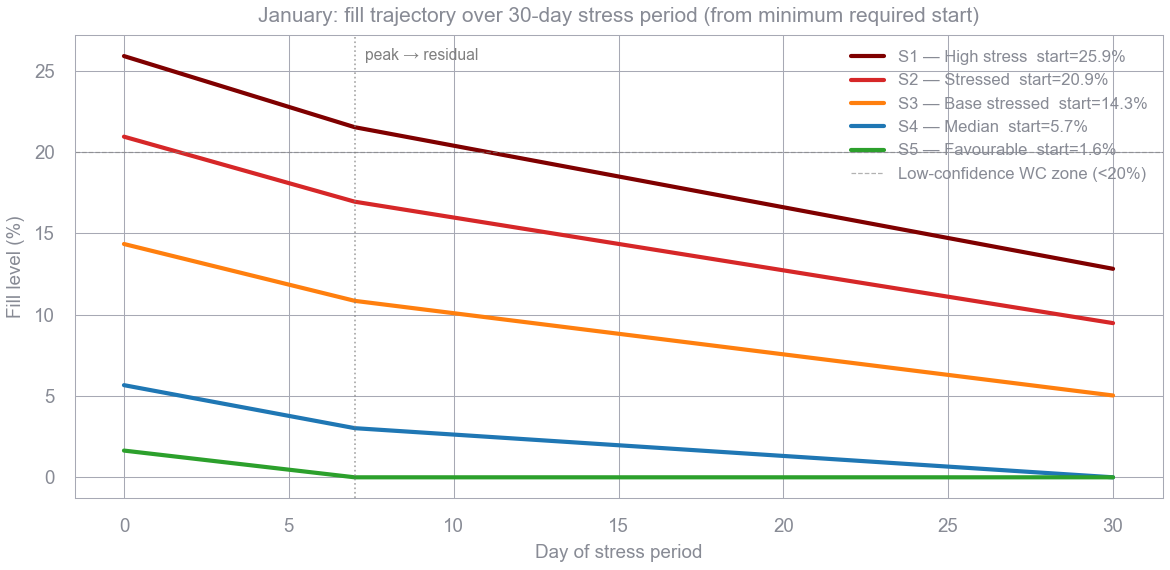

In [10]:
# Fill trajectories for January under each scenario
fig, ax = plt.subplots(figsize=(8, 4))

for key, sc in SCENARIOS.items():
    info = results[key][1]  # January
    traj = info["sim"]["fill_trajectory"]
    f    = info["start_fill_pct"]
    ax.plot(range(len(traj)), traj, color=sc.color, lw=2,
            label=f"{sc.label}  start={f:.1f}%" if f is not None else sc.label)

ax.axvline(bsd.STRESS_PEAK_DAYS, color="grey", lw=0.8, ls=":", alpha=0.7)
ax.text(bsd.STRESS_PEAK_DAYS + 0.3, ax.get_ylim()[1] * 0.97, "peak \u2192 residual",
        fontsize=7.5, color="grey", va="top")
ax.axhline(20, color="grey", lw=0.6, ls="--", alpha=0.6,
           label="Low-confidence WC zone (<20%)")
ax.set_xlabel("Day of stress period")
ax.set_ylabel("Fill level (%)")
ax.set_title("January: fill trajectory over 30-day stress period (from minimum required start)")
ax.legend(fontsize=8)
jvs.grid(ax=ax)
fig.tight_layout()
fig.savefig("figs/storage_obligations_jan_trajectories.png", bbox_inches="tight")
fig;

---
## 6. Regulatory summary table

Primary regulatory output: minimum TWh at month start per scenario.
S2 (P20 imports) is the **recommended planning anchor**.

In [11]:
rows = []
for m in bsd.MONTH_ORDER:
    row = {"Month": bsd.MONTH_NAMES[m]}
    for key, sc in SCENARIOS.items():
        info = results[key][m]
        v, b = info["start_fill_TWh"], info["binding"]
        if v is None:
            row[sc.label] = "infeasible"
        elif v == 0.0:
            row[sc.label] = "0.00"
        else:
            marker = " \u2605" if b == "withdrawal rate" else ""
            row[sc.label] = f"{v:.2f}{marker}"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Month")
print("\u2605 withdrawal-rate binding  (blank = volume binding)")
print(f"Czech UGS total capacity: {bsd.CAPACITY_TWH} TWh")
print("Recommended end-of-season operational floor (separate instrument): ~0.5 TWh at Mar 31\n")
summary_df

★ withdrawal-rate binding  (blank = volume binding)
Czech UGS total capacity: 40.7739 TWh
Recommended end-of-season operational floor (separate instrument): ~0.5 TWh at Mar 31



,S1 — High stress,S2 — Stressed,S3 — Base stressed,S4 — Median,S5 — Favourable
Month,,,,,
Oct,0.00,0.00,0.00,0.00,0.00
Nov,1.36,1.01,0.10,0.00,0.00
Dec,4.50 ★,4.12 ★,3.41 ★,0.46,0.00
Jan,10.56 ★,8.54 ★,5.85 ★,2.31,0.67
Feb,6.12 ★,3.62 ★,2.19,1.30,0.58
Mar,1.19,0.34,0.21,0.00,0.00


---
## 7. Ceiling-import benchmark (P99, cold days)

In [12]:
# Obligations under ceiling imports (all scenarios)
ceiling_rows = []
for key, sc in SCENARIOS.items():
    imp_ceiling_d = {m: float(IMPORT_CEILING[m]) for m in bsd.MONTH_ORDER}
    ceiling_imp_series = {k: pd.Series(imp_ceiling_d) for k in SCENARIOS}

    f = bsd.min_start_fill_month(1, float(IMPORT_CEILING[1]), wc_func, peak_demand, residual_demand)
    # Run full ceiling obligations table month by month
    ceiling_obligations = {}
    for m in bsd.MONTH_ORDER:
        fi = bsd.min_start_fill_month(m, float(IMPORT_CEILING[m]),
                                       wc_func, peak_demand, residual_demand)
        ceiling_obligations[bsd.MONTH_NAMES[m]] = (
            round(fi * bsd.CAPACITY_TWH / 100, 2) if fi is not None else None
        )
    break  # ceiling is import-assumption-driven, not scenario-driven

ceiling_df = pd.DataFrame([ceiling_obligations], index=["Obligation (TWh)"]).T
print(f"Ceiling assumption: {IMPORT_ASSUMPTION}")
print(f"P99 cold-day imports used:")
print(IMPORT_CEILING.rename(bsd.MONTH_NAMES).round(1).to_string())
print()
ceiling_df

Ceiling assumption: p99_cold
P99 cold-day imports used:
Oct    360.9
Nov    351.6
Dec    387.5
Jan    217.3
Feb    258.3
Mar    742.7



,Obligation (TWh)
Oct,0.00
Nov,0.00
Dec,0.00
Jan,2.20
Feb,0.48
Mar,0.00


---
## 8. Caveats

1. **Monthly independence.** Each obligation is a standalone 30-day stress test.
2. **Deterministic imports.** Month-specific percentiles applied as constants — conservative upper-bound.
3. **Withdrawal curve at low fill (<20%).** Poorly identified empirically; blend mitigates this.
4. **Demand/import correlation.** Commercially driven (not infrastructural); model is conservative on imports.
5. **End-of-season reserve.** ~0.5 TWh at Mar 31 recommended as a separate standalone instrument.
6. **Czech monthly framing vs. EU floating window.** Conservative and administratively tractable.